In [14]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [15]:
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet  # более простой для начала
from torch.utils.data import DataLoader, random_split

# Преобразования для тренировки (с аугментацией)
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Преобразования для валидации (без аугментации)
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = OxfordIIITPet(root='./data', split='trainval', transform=train_transform, download=True)

# Разделение на train (80%) и val (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Применяем разные трансформации для валидации
val_dataset.dataset.transform = val_transform

# Создаем DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Обучающие выборки: {len(train_dataset)}")
print(f"Тестовые выборки: {len(val_dataset)}")
print(f"Число классов: {len(full_dataset.classes)}")

Обучающие выборки: 2944
Тестовые выборки: 736
Число классов: 37


In [16]:
import torchvision.models as models
import torch.nn as nn

# Загрузка предобученной модели
model = models.resnet18(pretrained=True)

# Заморозка всех слоев
for param in model.parameters():
    param.requires_grad = False

num_classes = len(full_dataset.classes)  # 37 классов
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Размораживаем только новый слой
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(f"Архитектура модели изменена для {num_classes} классов")

Архитектура модели изменена для 37 классов


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [18]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

# Обучение
num_epochs = 15
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0

print("Обучение началось...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Лучшая модель сохранена! (Acc: {best_val_acc:.2f}%)")

print(f"\nОбучение завершено! Лучшая точность валидации: {best_val_acc:.2f}%")

Обучение началось...

Epoch 1/15


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.07it/s]


Train Loss: 2.2442, Train Acc: 47.15%
Val Loss: 1.2363, Val Acc: 73.10%
Лучшая модель сохранена! (Acc: 73.10%)

Epoch 2/15


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.08it/s]


Train Loss: 0.9846, Train Acc: 79.86%
Val Loss: 0.7544, Val Acc: 84.92%
Лучшая модель сохранена! (Acc: 84.92%)

Epoch 3/15


...

Train Loss: 0.2488, Train Acc: 93.99%
Val Loss: 0.4079, Val Acc: 87.77%

Epoch 14/15


Validation: 100%|██████████| 23/23 [00:04<00:00,  4.97it/s]


Train Loss: 0.2376, Train Acc: 93.75%
Val Loss: 0.4315, Val Acc: 87.36%

Epoch 15/15


Validation: 100%|██████████| 23/23 [00:05<00:00,  3.98it/s]

Train Loss: 0.2187, Train Acc: 94.67%
Val Loss: 0.4281, Val Acc: 86.96%

Обучение завершено! Лучшая точность валидации: 87.77%


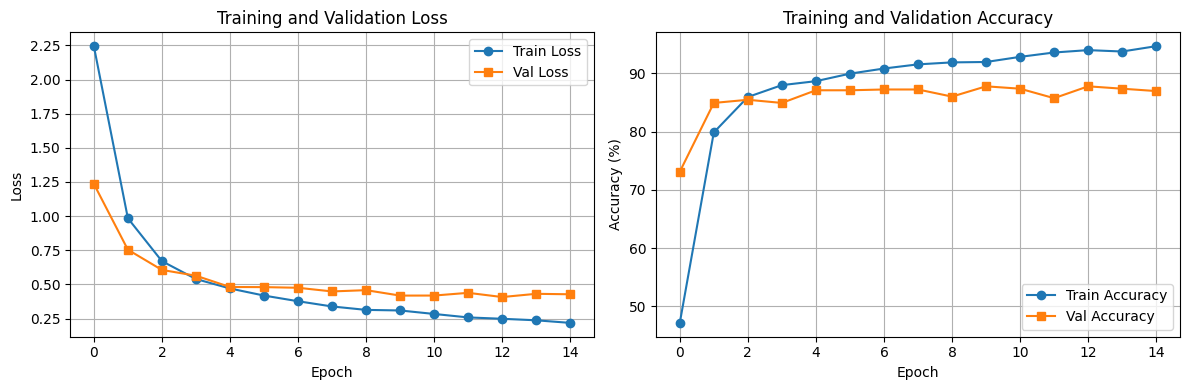

In [19]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss график
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy график
ax2.plot(train_accs, label='Train Accuracy', marker='o')
ax2.plot(val_accs, label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

Evaluating: 100%|██████████| 23/23 [00:04<00:00,  5.07it/s]



Classification Report:
                            precision    recall  f1-score   support

                Abyssinian       0.81      0.94      0.87        18
          American Bulldog       0.72      0.75      0.73        24
 American Pit Bull Terrier       0.70      0.82      0.76        17
              Basset Hound       0.88      0.88      0.88        25
                    Beagle       0.57      0.85      0.68        20
                    Bengal       0.89      0.76      0.82        21
                    Birman       1.00      0.87      0.93        15
                    Bombay       0.96      1.00      0.98        23
                     Boxer       0.81      0.81      0.81        21
         British Shorthair       0.82      0.95      0.88        19
                 Chihuahua       0.90      0.78      0.84        23
              Egyptian Mau       0.89      0.89      0.89        18
    English Cocker Spaniel       0.85      0.79      0.81        14
            English Set

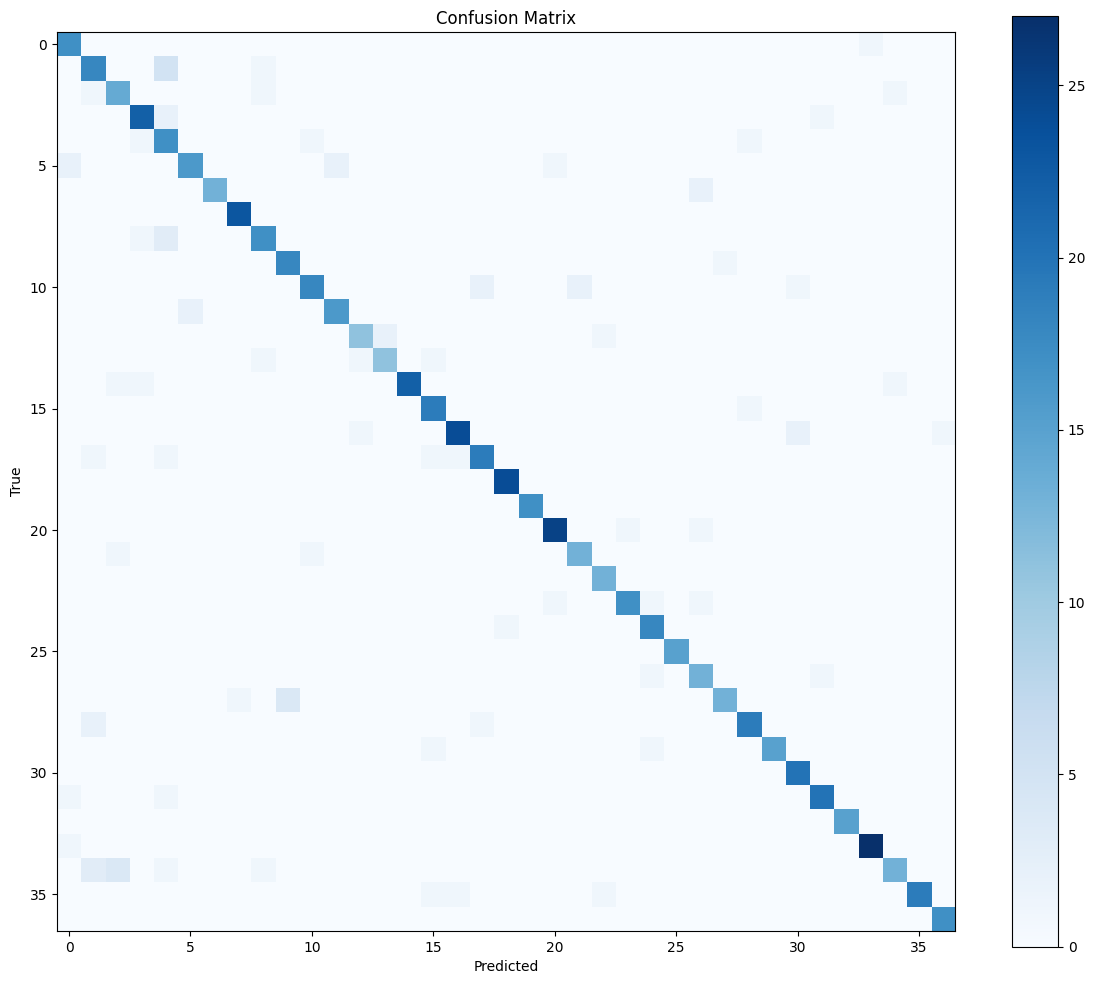

In [20]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Собираем предсказания для всего validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix shape:", cm.shape)

# Визуализация confusion matrix (для компактности покажем только часть)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

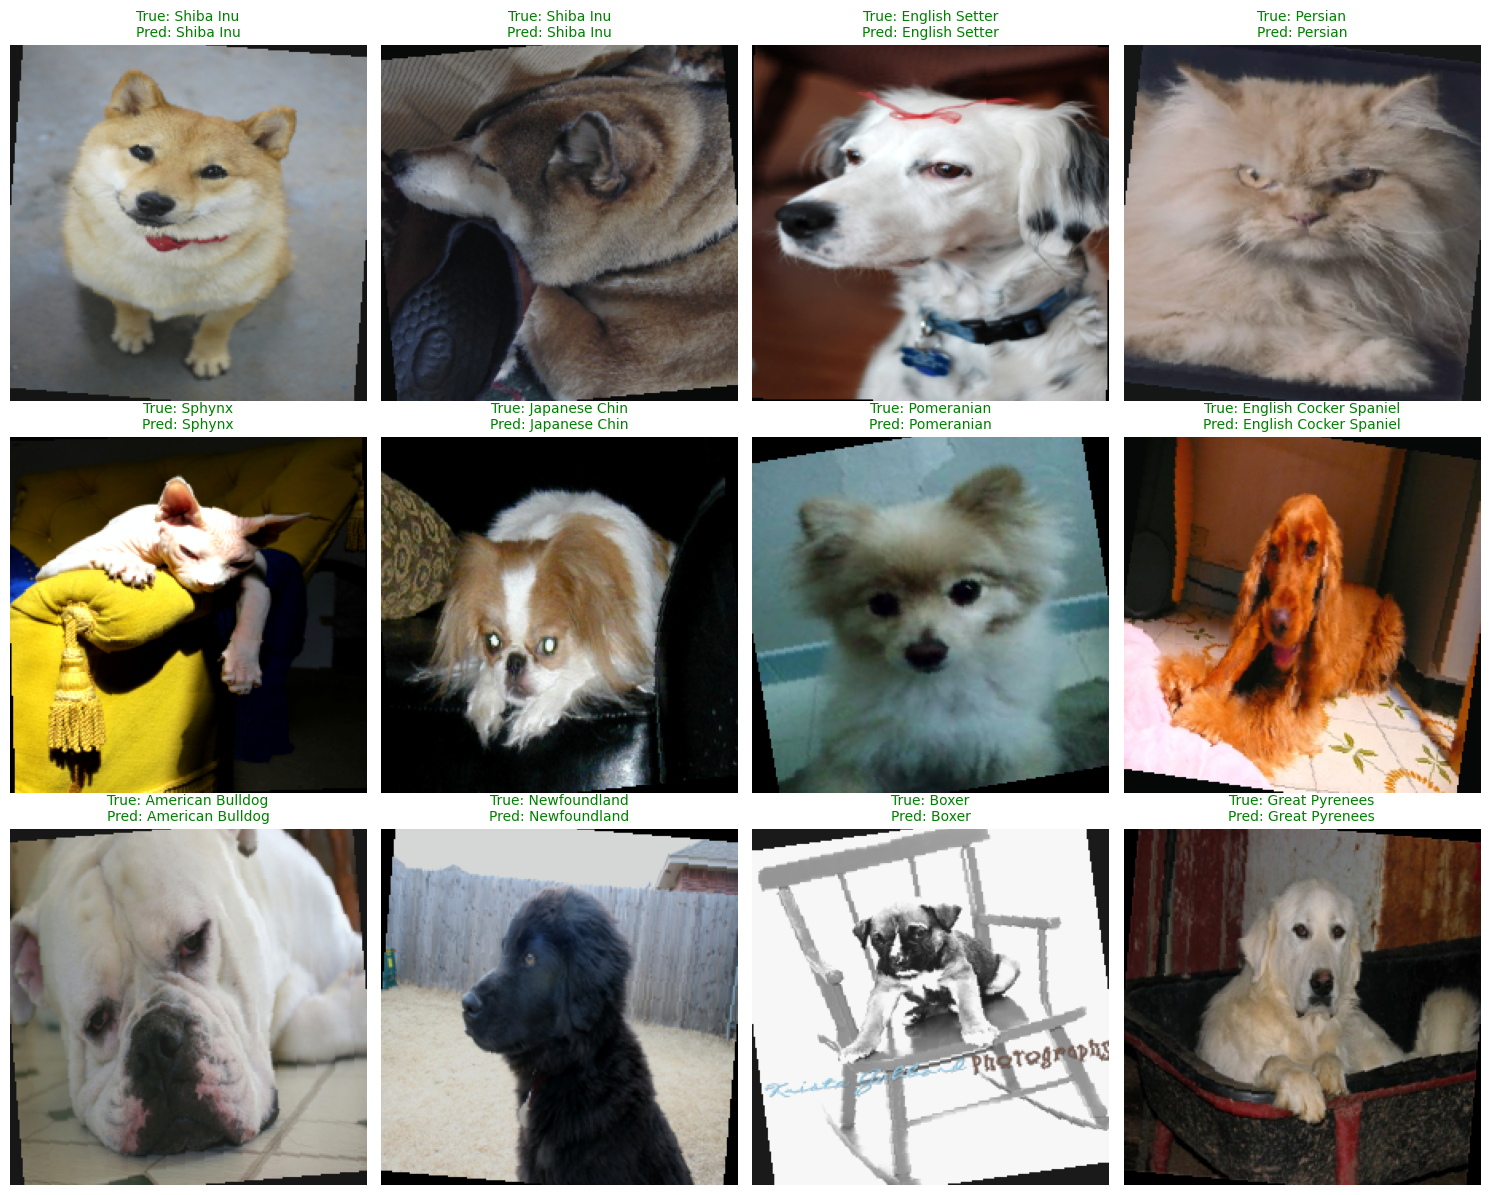

In [22]:
def imshow(ax, img, title=None, color='black'):
    """Отображение изображения на указанном подграфике"""
    # Конвертируем тензор в изображение
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # denormalize
    img = np.clip(img, 0, 1)

    # Отображаем
    ax.imshow(img)
    if title:
        ax.set_title(title, color=color, fontsize=10)
    ax.axis('off')

# Визуализация
model.eval()
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.ravel()

with torch.no_grad():
    for idx, (images, labels) in enumerate(val_loader):
        if idx >= 12:
            break

        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        # Берем первое изображение из батча
        img = images[0].cpu()
        true_label = labels[0].item()
        pred_label = predicted[0].item()

        true_name = full_dataset.classes[true_label]
        pred_name = full_dataset.classes[pred_label]
        title = f"True: {true_name}\nPred: {pred_name}"
        color = 'green' if true_label == pred_label else 'red'

        # Рисуем изображение на конкретном подграфике
        imshow(axes[idx], img, title, color)

        # Добавляем рамку (работает с тем же подграфиком)
        for spine in axes[idx].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('predictions_visualization.png', dpi=150)
plt.show()